In [14]:
import pandas as pd
import seaborn as sns

In [3]:
data_path = '../data'

In [4]:
df=pd.read_csv(data_path + "/raw/raw1.csv")
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [5]:
df.shape

(5000, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   str    
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64  
dtypes: 

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

In [8]:
df.isna().sum()

Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Date,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2025-01-04 20:34:04.800000,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
min,2024-01-01 00:00:00,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,2024-07-03 00:00:00,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,2025-01-06 00:00:00,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,2025-07-09 00:00:00,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,2025-12-31 00:00:00,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000
std,NaN,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205


# Numerical Columns

### Monthly Shipment Trend

In [23]:
df["Month"] = df["Date"].dt.to_period("M")

<Axes: xlabel='Month'>

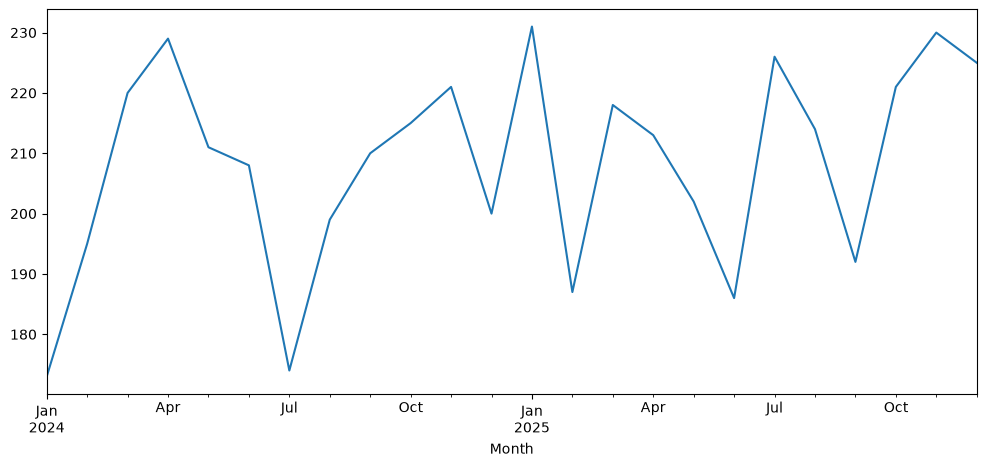

In [25]:
monthly_shipments = df.groupby("Month").size()

monthly_shipments.plot(
    figsize=(12,5)
)

Shipment volume remains relatively stable throughout the two-year period, indicating balanced operational activity and reducing the risk of temporal bias in predictive modeling.

### Disruption Prediction

In [12]:
df['Disruption_Occurred'].value_counts()

Disruption_Occurred
1    3063
0    1937
Name: count, dtype: int64

In [13]:
df["Disruption_Occurred"].value_counts(normalize=True)*100

Disruption_Occurred
1    61.26
0    38.74
Name: proportion, dtype: float64

<Axes: xlabel='Disruption_Occurred', ylabel='count'>

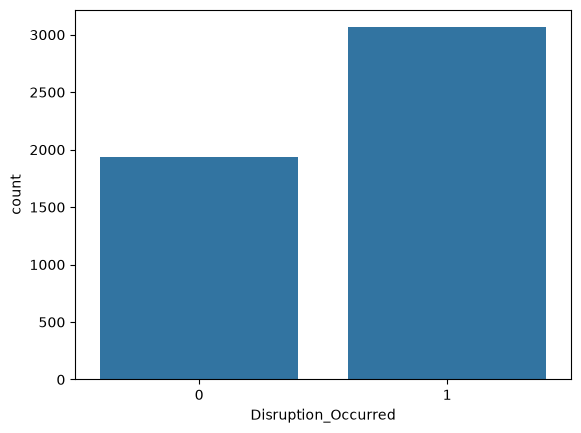

In [15]:
sns.countplot(
    data=df,
    x="Disruption_Occurred"
)

The dataset shows a moderate class imbalance toward disrupted shipments, suggesting disruptions are relatively common in the simulated supply chain environment.

### Lead Time Days

In [16]:
df["Lead_Time_Days"].skew()

np.float64(3.349222712647645)

<Axes: xlabel='Lead_Time_Days', ylabel='Count'>

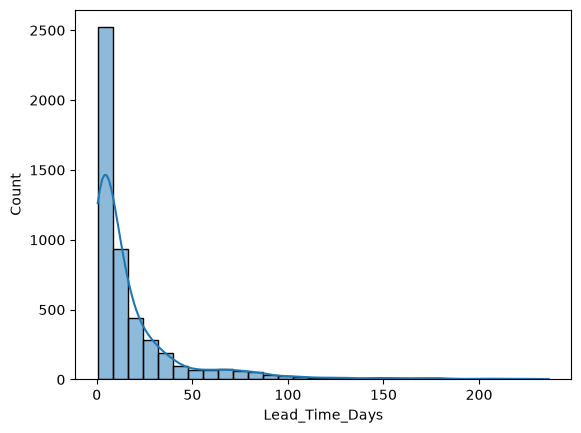

In [17]:
sns.histplot(
    df["Lead_Time_Days"],
    bins=30,
    kde=True
)

Lead time exhibits substantial positive skewness (3.35), indicating the presence of rare but severe shipment delays.

### Carrier Reliability Score

In [19]:
df["Carrier_Reliability_Score"].describe()

count    5000.000000
mean        0.754387
std         0.144363
min         0.500000
25%         0.629000
50%         0.757000
75%         0.879000
max         1.000000
Name: Carrier_Reliability_Score, dtype: float64

<Axes: xlabel='Carrier_Reliability_Score', ylabel='Count'>

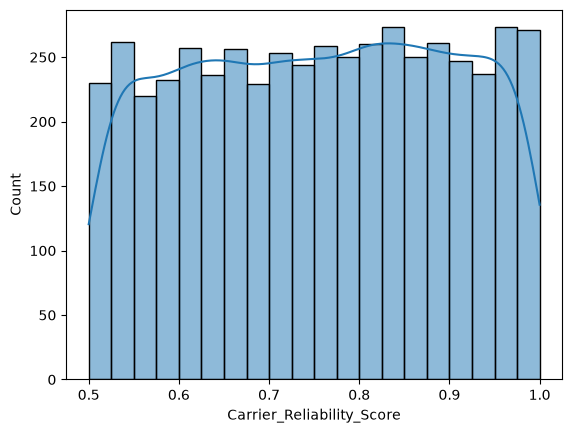

In [18]:
sns.histplot(
    df["Carrier_Reliability_Score"],
    bins=20,
    kde=True
)

Carrier reliability scores are evenly distributed across the full operational range[0.5, 1], providing balanced representation of carrier performance levels.

### Risk Score

<Axes: xlabel='Geopolitical_Risk_Score', ylabel='Count'>

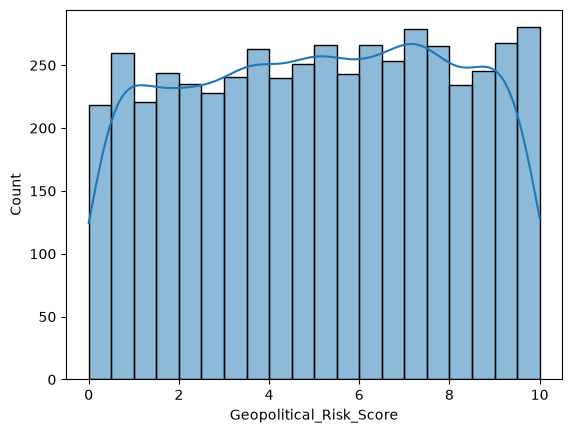

In [20]:
sns.histplot(
    df["Geopolitical_Risk_Score"],
    bins=20,
    kde=True
)

Geopolitical risk levels are broadly distributed across the entire scale, enabling effective learning of disruption patterns under varying risk environments.

# Catagorical Columns

In [11]:
df.describe(include='object')

C:\Users\thean\AppData\Local\Temp\ipykernel_31584\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Shipment_ID,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Weather_Condition
count,5000,5000,5000,5000,5000,5000
unique,5000,8,9,4,5,5
top,SC-10000,Busan,Marseille,Air,Electronics,Fog
freq,1,667,583,1320,1016,1036


In [12]:
for col in ["Origin_Port","Destination_Port","Transport_Mode",
            "Product_Category","Weather_Condition"]:
    print("\n", col)
    print(df[col].nunique())
    print(df[col].unique()[:20])


 Origin_Port
8
<StringArray>
[  'Singapore',   'Rotterdam',       'Busan',    'Shanghai',       'Dubai',
 'Los Angeles',     'Hamburg',     'Antwerp']
Length: 8, dtype: str

 Destination_Port
9
<StringArray>
['Los Angeles',    'Shanghai',     'Hamburg',   'Singapore',   'Marseille',
     'Antwerp',   'Rotterdam',       'Busan',       'Dubai']
Length: 9, dtype: str

 Transport_Mode
4
<StringArray>
['Rail', 'Air', 'Road', 'Sea']
Length: 4, dtype: str

 Product_Category
5
<StringArray>
['Textiles', 'Automotive', 'Perishables', 'Electronics', 'Pharmaceuticals']
Length: 5, dtype: str

 Weather_Condition
5
<StringArray>
['Hurricane', 'Storm', 'Rain', 'Fog', 'Clear']
Length: 5, dtype: str


### Routes

In [21]:
df["Route"] = (
    df["Origin_Port"]
    + " → "
    + df["Destination_Port"]
)

In [22]:
df["Route"].nunique()

64

### Weather Distribution

In [26]:
df["Weather_Condition"].value_counts()

Weather_Condition
Fog          1036
Storm        1002
Clear         995
Hurricane     990
Rain          977
Name: count, dtype: int64

### Mode Distribution

In [27]:
df["Transport_Mode"].value_counts()

Transport_Mode
Air     1320
Sea     1281
Road    1214
Rail    1185
Name: count, dtype: int64

# Bivariate Analysis

### Mode vs Lead time delay

In [40]:
df.groupby("Transport_Mode")["Lead_Time_Days"].agg(
    ["mean","median","std","min","max"]
)

,mean,median,std,min,max
Transport_Mode,,,,,
Air,1.644273,0.930,1.736741,0.5,8.63
Rail,19.954253,11.540,22.520365,0.5,117.76
Road,16.452306,9.295,19.412041,0.5,102.30
Sea,39.802966,21.790,47.668810,0.5,236.39


### Weather vs Lead Time Delay

In [39]:
df.groupby("Weather_Condition")["Lead_Time_Days"].agg(
    ["mean","median","std","min","max"]
)

,mean,median,std,min,max
Weather_Condition,,,,,
Clear,6.698704,5.130,6.549034,0.5,30.09
Fog,9.892847,7.000,9.974468,0.5,45.37
Hurricane,53.501848,40.030,53.509013,0.5,236.39
Rain,7.736049,5.980,7.457148,0.5,34.53
Storm,19.299182,14.725,18.976000,0.5,87.94


### Weather vs Disruption

In [28]:
weather_risk = (
    df.groupby("Weather_Condition")
      ["Disruption_Occurred"]
      .mean()
      .sort_values(ascending=False)
)

weather_risk

Weather_Condition
Hurricane    1.000000
Storm        0.795409
Fog          0.480695
Rain         0.419652
Clear        0.369849
Name: Disruption_Occurred, dtype: float64

### Mode vs Disruption

In [42]:
df.groupby("Transport_Mode")["Disruption_Occurred"].mean()

Transport_Mode
Air     0.617424
Rail    0.611814
Road    0.610379
Sea     0.610461
Name: Disruption_Occurred, dtype: float64

### Route vs Disruption

In [47]:
route_risk = (
    df.groupby("Route")
      ["Disruption_Occurred"]
      .mean()
      .sort_values(ascending=False)
)

print(route_risk.head(10))
print(route_risk.tail(10))

Route
Rotterdam → Marseille      0.750000
Los Angeles → Singapore    0.720588
Hamburg → Rotterdam        0.708333
Rotterdam → Busan          0.686047
Busan → Shanghai           0.681319
Singapore → Antwerp        0.680556
Shanghai → Singapore       0.677419
Busan → Marseille          0.676923
Hamburg → Los Angeles      0.670588
Shanghai → Marseille       0.662338
Name: Disruption_Occurred, dtype: float64
Route
Hamburg → Singapore        0.565789
Rotterdam → Hamburg        0.558140
Rotterdam → Shanghai       0.556962
Antwerp → Rotterdam        0.556701
Singapore → Marseille      0.552239
Los Angeles → Marseille    0.541667
Los Angeles → Rotterdam    0.539474
Los Angeles → Hamburg      0.525424
Rotterdam → Dubai          0.493976
Busan → Los Angeles        0.482759
Name: Disruption_Occurred, dtype: float64


### Risk Level Analysis

### Risk level vs Disruption

In [56]:
df["Risk_Level"] = pd.cut(
    df["Geopolitical_Risk_Score"],
    bins=[0,3,7,10],
    labels=["Low","Medium","High"],
    include_lowest=True
)

In [57]:
df.groupby("Risk_Level")["Disruption_Occurred"].mean()

Risk_Level
Low       0.475829
Medium    0.617053
High      0.736704
Name: Disruption_Occurred, dtype: float64

In [60]:
df.groupby("Risk_Level")["Lead_Time_Days"].agg(
    ["count","mean","median","std","max","min"]
)

,count,mean,median,std,max,min
Risk_Level,,,,,,
Low,1448,15.790601,6.80,26.280879,186.22,0.5
Medium,2029,19.237792,8.21,29.662769,209.65,0.5
High,1523,22.901287,9.78,37.224975,236.39,0.5


### Reliability Level Analysis

### Reliability level vs Disruption

In [58]:
df["Reliability_Level"] = pd.cut(
    df["Carrier_Reliability_Score"],
    bins=[0.5,0.65,0.85,1.0],
    labels=["Low","Medium","High"],
    include_lowest=True
)

In [59]:
df.groupby("Reliability_Level")["Disruption_Occurred"].mean()

Reliability_Level
Low       0.653075
Medium    0.623138
High      0.560754
Name: Disruption_Occurred, dtype: float64

In [61]:
df.groupby("Reliability_Level")["Lead_Time_Days"].agg(
    ["count","mean","median","std","max","min"]
)

,count,mean,median,std,max,min
Reliability_Level,,,,,,
Low,1447,19.780657,8.410,31.348695,234.84,0.5
Medium,2014,19.456241,8.005,32.418394,236.39,0.5
High,1539,18.823554,8.240,30.096304,233.78,0.5
